Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

Download NLTK Data

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset

In [5]:
df = pd.read_csv("Resume.csv")

In [6]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Read Job Description

In [11]:
from google.colab import files

uploaded = files.upload()

Saving job_description.txt to job_description.txt


In [15]:
with open("job_description.txt", "r") as file:
    job_description = file.read()

In [16]:
print(job_description)

We are looking for a Machine Learning Intern.

Required Skills:
Python
Machine Learning
Data Analysis
SQL
Pandas
NumPy
Scikit-learn
Deep Learning
Communication
Problem Solving


Clean Resume Text

In [17]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = word_tokenize(text)

    stop_words = set(stopwords.words('english'))

    text = [word for word in text if word not in stop_words]

    return " ".join(text)

In [20]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
df['Clean_Resume'] = df['Resume_str'].apply(clean_text)

In [22]:
clean_job = clean_text(job_description)

Extract Skills Using spaCy

In [23]:
nlp = spacy.load("en_core_web_sm")

In [36]:
skills = [
    'python',
    'machine learning',
    'deep learning',
    'data analysis',
    'sql',
    'pandas',
    'numpy',
    'communication',
    'leadership',
    'java',
    'c++',
    'html',
    'css',
    'javascript',
    'power bi',
    'excel',
    'aws',
    'docker',
    'git',
    'scikit learn'
]

def extract_skills(text):
    text = text.lower()
    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return list(set(found))

In [26]:
df['Clean_Resume'] = df['Resume_str'].apply(clean_text)

In [38]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'Clean_Resume',
       'Similarity Score', 'Skills'],
      dtype='object')


Calculate Resume Similarity

In [27]:
vectorizer = TfidfVectorizer()

In [28]:
documents = [clean_job] + df['Clean_Resume'].tolist()

In [29]:
tfidf_matrix = vectorizer.fit_transform(documents)

In [30]:
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:])

In [31]:
df['Similarity Score'] = similarity[0]

In [39]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'Clean_Resume',
       'Similarity Score', 'Skills'],
      dtype='object')


Rank Candidates

In [41]:
ranked = df.sort_values(
    by="Similarity Score",
    ascending=False
)

In [42]:
ranked[['Category', 'Similarity Score', 'Skills']].head(10)

,Category,Similarity Score,Skills
2153,BANKING,0.192687,"[sql, python, machine learning]"
1339,AUTOMOBILE,0.186977,"[pandas, leadership, scikit learn, numpy, exce..."
926,AGRICULTURE,0.171023,"[pandas, javascript, leadership, communication..."
2291,ARTS,0.170097,[leadership]
1762,ENGINEERING,0.161996,"[pandas, excel, python, html, sql, data analys..."
194,DESIGNER,0.143341,[]
374,TEACHER,0.132110,"[communication, excel, leadership]"
349,TEACHER,0.123441,"[communication, git]"
1218,CONSULTANT,0.114999,"[javascript, java, python, sql, data analysis,..."
337,TEACHER,0.110795,"[communication, excel, leadership]"


Identify Missing Skills

In [43]:
job_skills = extract_skills(clean_job)

In [44]:
def missing(candidate):

    return list(set(job_skills)-set(candidate))

In [45]:
df['Missing Skills'] = df['Skills'].apply(missing)

Display Final Ranking

In [46]:
ranked = df.sort_values(
    by='Similarity Score',
    ascending=False
)

ranked.head(10)

,ID,Resume_str,Resume_html,Category,Clean_Resume,Similarity Score,Skills,Missing Skills
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,0.192687,"[sql, python, machine learning]","[pandas, deep learning, communication, scikit ..."
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial s...,0.186977,"[pandas, leadership, scikit learn, numpy, exce...","[deep learning, communication, machine learning]"
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,0.171023,"[pandas, javascript, leadership, communication...","[deep learning, numpy, data analysis, machine ..."
2291,12777487,ONLINE LEARNING COORDINATOR - PROGRAM...,"<div class=""fontsize fontface vmargins hmargin...",ARTS,online learning coordinator program training s...,0.170097,[leadership],"[pandas, deep learning, communication, scikit ..."
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering quality technician career overview...,0.161996,"[pandas, excel, python, html, sql, data analys...","[deep learning, numpy, scikit learn, communica..."
194,18835363,PROGRAM MANAGER & DESIGNER ...,"<div class=""skn-cbg1 fontsize fontface vmargin...",DESIGNER,program manager designer professional summary ...,0.143341,[],"[pandas, deep learning, communication, scikit ..."
374,36206485,TEACHER Summary An elementar...,"<div class=""fontsize fontface vmargins hmargin...",TEACHER,teacher summary elementary school teacher many...,0.132110,"[communication, excel, leadership]","[pandas, deep learning, scikit learn, numpy, p..."
349,90363254,TEACHER Summary Highly e...,"<div class=""fontsize fontface vmargins hmargin...",TEACHER,teacher summary highly ethical dependable dili...,0.123441,"[communication, git]","[pandas, deep learning, scikit learn, numpy, p..."
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,0.114999,"[javascript, java, python, sql, data analysis,...","[pandas, deep learning, communication, scikit ..."
337,12467531,TEACHER Professional Summary ...,"<div class=""LCA skn-cbg1 fontsize fontface vma...",TEACHER,teacher professional summary master teacher lo...,0.110795,"[communication, excel, leadership]","[pandas, deep learning, scikit learn, numpy, p..."


Visualization

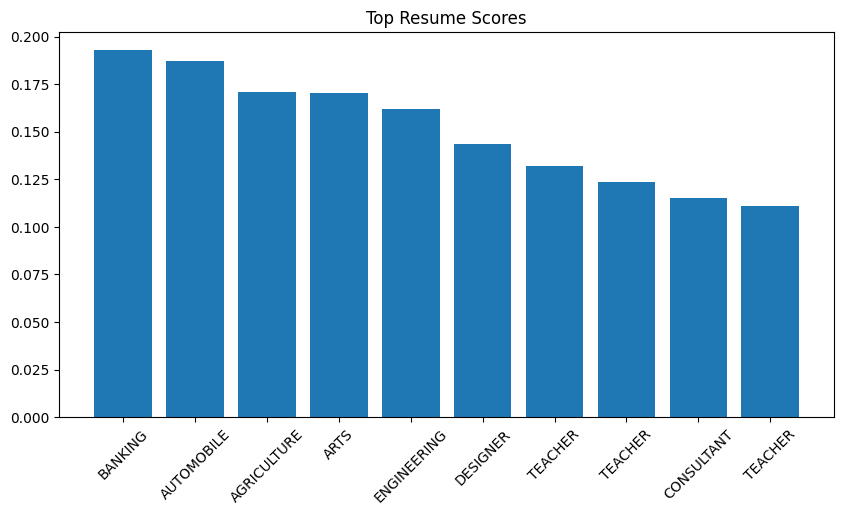

In [47]:
top = ranked.head(10)

plt.figure(figsize=(10,5))

plt.bar(range(len(top)),
        top['Similarity Score'])

plt.xticks(range(len(top)),
           top['Category'],
           rotation=45)

plt.title("Top Resume Scores")

plt.show()

Results

Resume Ranking Explanation
Candidates are ranked based on cosine similarity between their resume and the job description.

TF-IDF converts the text into numerical vectors.

Higher similarity scores indicate a better match for the job.

Missing skills are identified by comparing the candidate's extracted skills with the required job skills.

This helps recruiters quickly shortlist the most suitable applicants.

Display Individual Candidate Details

In [49]:
for i in range(5):
    print("="*60)
    print("Candidate:", i+1)
    print("Category:", ranked.iloc[i]['Category'])
    print("Similarity Score:", round(ranked.iloc[i]['Similarity Score']*100,2), "%")
    print("Skills:", ranked.iloc[i]['Skills'])
    print("Missing Skills:", ranked.iloc[i]['Missing Skills'])
    print()

Candidate: 1
Category: BANKING
Similarity Score: 19.27 %
Skills: ['sql', 'python', 'machine learning']
Missing Skills: ['pandas', 'deep learning', 'communication', 'scikit learn', 'numpy', 'data analysis']

Candidate: 2
Category: AUTOMOBILE
Similarity Score: 18.7 %
Skills: ['pandas', 'leadership', 'scikit learn', 'numpy', 'excel', 'python', 'sql', 'data analysis']
Missing Skills: ['deep learning', 'communication', 'machine learning']

Candidate: 3
Category: AGRICULTURE
Similarity Score: 17.1 %
Skills: ['pandas', 'javascript', 'leadership', 'communication', 'scikit learn', 'java', 'excel', 'python', 'html', 'sql', 'css']
Missing Skills: ['deep learning', 'numpy', 'data analysis', 'machine learning']

Candidate: 4
Category: ARTS
Similarity Score: 17.01 %
Skills: ['leadership']
Missing Skills: ['pandas', 'deep learning', 'communication', 'scikit learn', 'numpy', 'python', 'sql', 'data analysis', 'machine learning']

Candidate: 5
Category: ENGINEERING
Similarity Score: 16.2 %
Skills: ['pan

Conclusion

This project successfully implements a Resume Screening and Candidate Ranking System using Natural Language Processing techniques.

The system:
- Cleans resume text.
- Extracts technical skills.
- Compares resumes with a job description using TF-IDF and Cosine Similarity.
- Ranks candidates according to their relevance.
- Identifies missing skills for each candidate.

This project demonstrates how machine learning can support recruiters in automating resume screening and improving hiring efficiency.